#Sintéticos
Paola Restrepo Rojo.  
Sofía Vásquez Jaramillo.  
Luisa Fernanda Gomez Ossa.  
Agricultura predictiva
Mayo 12,2026.

In [71]:
# Importo librerias y de la semilla 42 que es como afinar las notas para que siempre sea el mismo dataset y no me cambie cada que corra el codigo.
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression #genera datos sinteticos con make regression y me permiee ponerle metrcas como min max scaler. . Libreria completa de machine lerning,.
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

Dataset sintético simulando rangos de datos de arroz en el Tolima. La variable objetivo(es decir la variable Y) sera rendimiento en t/ha.  


In [72]:
# Con Scikit-learn, en la clase 11 y la clase 4 practicamos cómo generar data sintética.
# make_regression crea 15 variables con pesos aleatorios y calcula su combinación lineal.
# Fue una decisión personal agregarle ruido para que el resultado no fuera perfecto,
# ya que vivimos en un mundo estocástico, donde los datos reales tienen variabilidad.
lotes          = 70
ciclos_por_año = 2   # ciclo 1 (abril-agosto) y ciclo 2 (septiembre-febrero)
años           = 8   # 2016 - 2023
n_samples      = lotes * ciclos_por_año * años  # = 1120

X, y = make_regression(
    n_samples     = n_samples,  # 1120 registros = 70 lotes × 2 ciclos × 8 años
    n_features    = 15,         # 15 variables agronómicas (nitrógeno, pH, NDVI...)
    n_informative = 15,         # todas las variables participan en la generación
    noise         = 0.8,        # error gaussiano: simula que la agricultura. 0.8 las variables explican algo per no todo.
                                # depende de factores naturales impredecibles
    random_state  = 42          # semilla fija → siempre el mismo dataset
)

print(f"Filas × Columnas de X : {X.shape}")
print(f"Tamaño de y           : {y.shape}")
print(f"Valor mínimo de y     : {y.min():.2f}  ← aún en escala estándar")
print(f"Valor máximo de y     : {y.max():.2f}  ← aún en escala estándar")
print(f"\nPrimeras 3 filas de X (todavía sin unidades agronómicas):")
print(X[:3].round(3))

Filas × Columnas de X : (1120, 15)
Tamaño de y           : (1120,)
Valor mínimo de y     : -677.04  ← aún en escala estándar
Valor máximo de y     : 674.18  ← aún en escala estándar

Primeras 3 filas de X (todavía sin unidades agronómicas):
[[ 0.399  0.022 -0.829  0.08  -0.662  0.077 -0.956 -0.399  1.184 -1.447
   0.257  0.122 -0.429 -0.309 -0.241]
 [-0.269 -1.803 -1.514  0.267  0.897 -0.483 -1.581  0.895  0.147  1.901
   1.612  0.509 -1.584 -0.061 -0.708]
 [ 0.957 -1.37   0.458  1.191 -0.619  2.211 -0.13   0.042  1.135  0.252
  -0.617  1.762 -0.007 -0.488  0.036]]


In [73]:
# Escalamos la variable y creada por make_regression para que el rendimiento
# tenga sentido agronómico y siga relacionado con las variables X.

from sklearn.preprocessing import MinMaxScaler

scaler_y = MinMaxScaler(feature_range=(4, 12))
#tener valores negativos no tiene sentido en rendimiento agro.

rendimiento = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
rendimiento = rendimiento.round(2)

print(f"Mínimo  : {rendimiento.min():.2f} t/ha")
print(f"Máximo  : {rendimiento.max():.2f} t/ha")
print(f"Promedio: {rendimiento.mean():.2f} t/ha")

Mínimo  : 4.00 t/ha
Máximo  : 12.00 t/ha
Promedio: 8.01 t/ha


In [74]:
#Le damos nombres a las variables (15)
#le damos rangos logicos como pH de la zona en el Tolima, calidad de agua en riego, que el ndvi en imagenes con drones o satelitales ente entre 0.3 y 0.8, etc.
rangos = {
    'nitrogeno'       : (80,  180),  # kg/ha  — fertilización nitrogenada
    'fosforo'         : (15,   60),  # kg/ha  — fertilización fosfatada
    'potasio'         : (40,  120),  # kg/ha  — fertilización potásica
    'ph'              : (5.5,  7.2), #        — suelos arroceros del Tolima
    'materia_organica': (1.5,  5.0), # %      — contenido orgánico del suelo
    'humedad_suelo'   : (40,   85),  # %      — capacidad de retención hídrica
    'cond_electrica'  : (0.1,  2.5), # dS/m   — salinidad del suelo
    'zinc'            : (0.5,  5.0), # mg/kg  — micronutriente crítico en arroz
    'silicio'         : (50,  250),  # mg/kg  — mejora resistencia a plagas
    'temperatura'     : (24,   32),  # °C     — rango térmico del Tolima
    'precipitacion'   : (100, 400),  # mm/mes — régimen de lluvias
    'ndvi'            : (0.35, 0.85),#        — índice de vegetación satelital
    'hectareas'       : (25,   50),  # ha     — tamaño de cada lote
    'num_caballones'  : (40,  120),  #        — surcos de drenaje por lote
    'ph_agua'         : (6.0,  7.5), #        — calidad del agua de riego
}

# Aplicar Min-Max columna por columna
df_vars = pd.DataFrame()
for i, (col, (lo, hi)) in enumerate(rangos.items()):
    col_std      = (X[:, i] - X[:, i].min()) / (X[:, i].max() - X[:, i].min())
    df_vars[col] = (lo + col_std * (hi - lo)).round(2)

# Verificar que los rangos quedaron bien
print(df_vars.describe().round(2))

       nitrogeno  fosforo  potasio       ph  materia_organica  humedad_suelo  \
count    1120.00  1120.00  1120.00  1120.00           1120.00        1120.00   
mean      126.13    36.27    74.01     6.38              3.16          64.00   
std        13.86     7.17    10.38     0.23              0.56           6.18   
min        80.00    15.00    40.00     5.50              1.50          40.00   
25%       117.26    31.39    67.28     6.23              2.79          59.84   
50%       126.30    36.20    74.18     6.38              3.18          63.93   
75%       134.82    41.35    80.70     6.52              3.54          68.10   
max       180.00    60.00   120.00     7.20              5.00          85.00   

       cond_electrica     zinc  silicio  temperatura  precipitacion     ndvi  \
count         1120.00  1120.00  1120.00      1120.00        1120.00  1120.00   
mean             1.27     2.98   151.80        27.58         264.23     0.60   
std              0.37     0.75    30.78

In [75]:
#70 lotes × 2 ciclos × 8 años = 1120 registros. Se ensambla el DataFrame final
n_lotes      = 70
n_ciclos     = 2
n_años       = 8
años_rango   = range(2016, 2024)      # 2016–2023
obs_por_lote = n_ciclos * n_años      # 16 observaciones por lote
total        = n_lotes * obs_por_lote # 1120

# ── Identificadores CORREGIDOS
# cada año tiene ciclo 1 (70 lotes) Y ciclo 2 (70 lotes)
años_col   = np.repeat(list(años_rango) * n_ciclos, n_lotes)[:total]
ciclos_col = np.repeat([1, 2], n_lotes * n_años)[:total]
lotes_col  = np.tile([f'Lote_{i:02d}' for i in range(1, n_lotes + 1)], n_ciclos * n_años)[:total]

# ── Ensamblar
df = df_vars.copy()
df.insert(0, 'año',          años_col)
df.insert(1, 'ciclo',        ciclos_col)
df.insert(2, 'lote',         lotes_col)
df.insert(3, 'cultivo',      'Arroz')
df.insert(4, 'departamento', 'Tolima')
df['rendimiento']     = rendimiento
df['rendimiento_cat'] = (df['rendimiento'] >= df['rendimiento'].median()).astype(int)

# ── Nulos intencionales (~5% por columna)
cols_nulos = ['nitrogeno', 'fosforo', 'zinc', 'humedad_suelo', 'ndvi', 'silicio']
for i, col in enumerate(cols_nulos):
    df.loc[df.sample(frac=0.05, random_state=42+i).index, col] = np.nan

# ── Atípicos intencionales
df.loc[df.sample(3, random_state=1).index, 'precipitacion']  = [650, 720, 800]
df.loc[df.sample(2, random_state=2).index, 'cond_electrica'] = [6.5, 8.0]

# ── Verificación
print(df.groupby(['año', 'ciclo'])['rendimiento'].count().unstack())

# ── Resumen final
print(f"\nDataset listo")
print(f"  Forma          : {df.shape}")
print(f"  Años           : {df['año'].min()} – {df['año'].max()}")
print(f"  Lotes          : {df['lote'].nunique()}")
print(f"  Ciclos         : {df['ciclo'].unique()}")

ciclo   1   2
año          
2016   70  70
2017   70  70
2018   70  70
2019   70  70
2020   70  70
2021   70  70
2022   70  70
2023   70  70

Dataset listo
  Forma          : (1120, 22)
  Años           : 2016 – 2023
  Lotes          : 70
  Ciclos         : [1 2]


In [76]:
# La mediana estaba alrededor de 8 t/ha, que corresponde aproximadamente
# al punto medio del rango agronómico real del arroz en el Tolima.
# Esto permitió que el umbral tuviera no solo sentido estadístico,
# sino también sentido biológico y agronómico.

# A los registros que estaban por debajo de este valor se les asignó
# la categoría 0, mientras que a los que estaban por encima se les
# asignó la categoría 1.

# Además, transformar el problema a una clasificación binaria puede
# ayudar a que el modelo tenga menos error, se entrene de una manera
# más estable y sea más fácil de interpretar y aplicar por agricultores
# del Tolima en contextos reales.

In [77]:
#guarda esto sintético en un csv por facilidad
df.to_csv('arroz_tolima.csv', index=False)
df_csv = pd.read_csv('arroz_tolima.csv')

print(f" CSV guardado y leído correctamente")
print(f"  Forma: {df_csv.shape}")

 CSV guardado y leído correctamente
  Forma: (1120, 22)


In [78]:
# explorar tipo de variable
print(type(df))
#asi hacemos un chqueo de que se puede tratar como un dataframe.

<class 'pandas.core.frame.DataFrame'>


In [79]:
# tamaño del dataset
df.shape
#1120 registros * 22 columnas.

(1120, 22)

In [80]:
# leer los primeros 5 registros
df.head(5)

,año,ciclo,lote,cultivo,departamento,nitrogeno,fosforo,potasio,ph,materia_organica,...,zinc,silicio,temperatura,precipitacion,ndvi,hectareas,num_caballones,ph_agua,rendimiento,rendimiento_cat
0,2016,1,Lote_01,Arroz,Tolima,131.38,36.36,65.47,6.39,2.79,...,2.66,186.39,25.99,278.16,0.61,37.63,78.26,6.68,7.21,0
1,2016,1,Lote_02,Arroz,Tolima,121.98,23.15,58.43,6.43,3.64,...,3.66,154.98,29.73,340.22,0.64,33.45,81.41,6.56,8.86,1
2,2016,1,Lote_03,Arroz,Tolima,139.23,26.29,78.69,6.65,2.81,...,3.00,184.89,27.89,238.15,0.74,39.16,76.00,6.75,9.27,1
3,2016,1,Lote_04,Arroz,Tolima,126.78,45.78,74.18,5.93,2.91,...,1.81,151.57,25.87,242.93,0.54,37.19,101.25,7.12,7.73,0
4,2016,1,Lote_05,Arroz,Tolima,118.95,27.06,58.68,6.69,3.46,...,3.88,166.28,25.92,265.88,0.61,40.36,85.30,6.51,7.99,0


In [81]:
# ultimos 5 registros
df.tail(5)

,año,ciclo,lote,cultivo,departamento,nitrogeno,fosforo,potasio,ph,materia_organica,...,zinc,silicio,temperatura,precipitacion,ndvi,hectareas,num_caballones,ph_agua,rendimiento,rendimiento_cat
1115,2023,2,Lote_66,Arroz,Tolima,134.76,34.43,54.23,6.38,3.19,...,3.12,90.65,28.92,267.61,0.66,33.69,108.99,6.39,8.53,1
1116,2023,2,Lote_67,Arroz,Tolima,141.52,32.04,68.53,5.83,4.84,...,4.24,167.99,27.36,280.66,0.48,38.19,89.96,6.92,11.28,1
1117,2023,2,Lote_68,Arroz,Tolima,133.77,38.83,64.19,6.13,3.48,...,3.27,143.09,28.19,205.18,0.69,34.94,83.36,6.62,8.79,1
1118,2023,2,Lote_69,Arroz,Tolima,141.77,34.12,67.53,5.78,2.52,...,NaN,201.28,29.29,223.13,0.70,44.31,78.00,6.69,8.42,1
1119,2023,2,Lote_70,Arroz,Tolima,136.17,34.97,52.51,6.27,2.02,...,2.85,165.25,27.26,177.17,0.59,38.22,91.44,6.58,5.92,0


In [82]:
# estadísticas básicas de todas las variables numéricas
df.describe()

,año,ciclo,nitrogeno,fosforo,potasio,ph,materia_organica,humedad_suelo,cond_electrica,zinc,silicio,temperatura,precipitacion,ndvi,hectareas,num_caballones,ph_agua,rendimiento,rendimiento_cat
count,1120.000000,1120.000000,1064.000000,1064.000000,1120.000000,1120.000000,1120.000000,1064.000000,1120.000000,1064.000000,1064.000000,1120.000000,1120.000000,1064.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000
mean,2019.500000,1.500000,126.092256,36.273919,74.007991,6.375750,3.159777,63.943872,1.279295,2.978938,151.575103,27.583054,265.385196,0.601081,39.195634,82.102009,6.739134,8.009804,0.501786
std,2.292311,0.500223,13.738226,7.156141,10.376685,0.232728,0.558871,6.224629,0.451340,0.753176,30.976327,1.165267,52.783018,0.079910,3.693884,12.828308,0.235037,1.339396,0.500220
min,2016.000000,1.000000,80.000000,15.000000,40.000000,5.500000,1.500000,40.000000,0.100000,0.500000,50.000000,24.000000,100.000000,0.350000,25.000000,40.000000,6.000000,4.000000,0.000000
25%,2017.750000,1.000000,117.375000,31.415000,67.277500,6.230000,2.790000,59.785000,1.010000,2.457500,131.000000,26.800000,230.247500,0.550000,36.837500,73.420000,6.580000,7.087500,0.000000
50%,2019.500000,1.500000,126.240000,36.185000,74.175000,6.380000,3.180000,63.795000,1.280000,2.950000,151.160000,27.600000,263.690000,0.600000,39.235000,81.835000,6.730000,8.010000,1.000000
75%,2021.250000,2.000000,134.722500,41.362500,80.700000,6.522500,3.542500,68.120000,1.520000,3.520000,171.755000,28.362500,297.475000,0.650000,41.742500,90.557500,6.890000,8.930000,1.000000
max,2023.000000,2.000000,180.000000,60.000000,120.000000,7.200000,5.000000,85.000000,8.000000,5.000000,250.000000,32.000000,800.000000,0.850000,50.000000,120.000000,7.500000,12.000000,1.000000


In [83]:
print(f"La mediana del rendimiento es: {df['rendimiento'].median():.2f} t/ha")

La mediana del rendimiento es: 8.01 t/ha


In [84]:
#56 nulos en 3 columnas, clases balanceadas, atipicos en orecipitacuion y condu electrica, rendimiento cooncetrado en 8 ton /ha.

In [85]:
# valores únicos por columna
df.nunique()

,0
año,8
ciclo,2
lote,70
cultivo,1
departamento,1
nitrogeno,960
fosforo,861
potasio,979
ph,124
materia_organica,247


In [86]:
# nulos por columna
df.isnull().sum()

,0
año,0
ciclo,0
lote,0
cultivo,0
departamento,0
nitrogeno,56
fosforo,56
potasio,0
ph,0
materia_organica,0


In [87]:
# da igual por que indujimos los nulos.

In [88]:
# duplicados
df.duplicated().sum()
#cero duplicados tiene sentido por que son sintéticos.

np.int64(0)

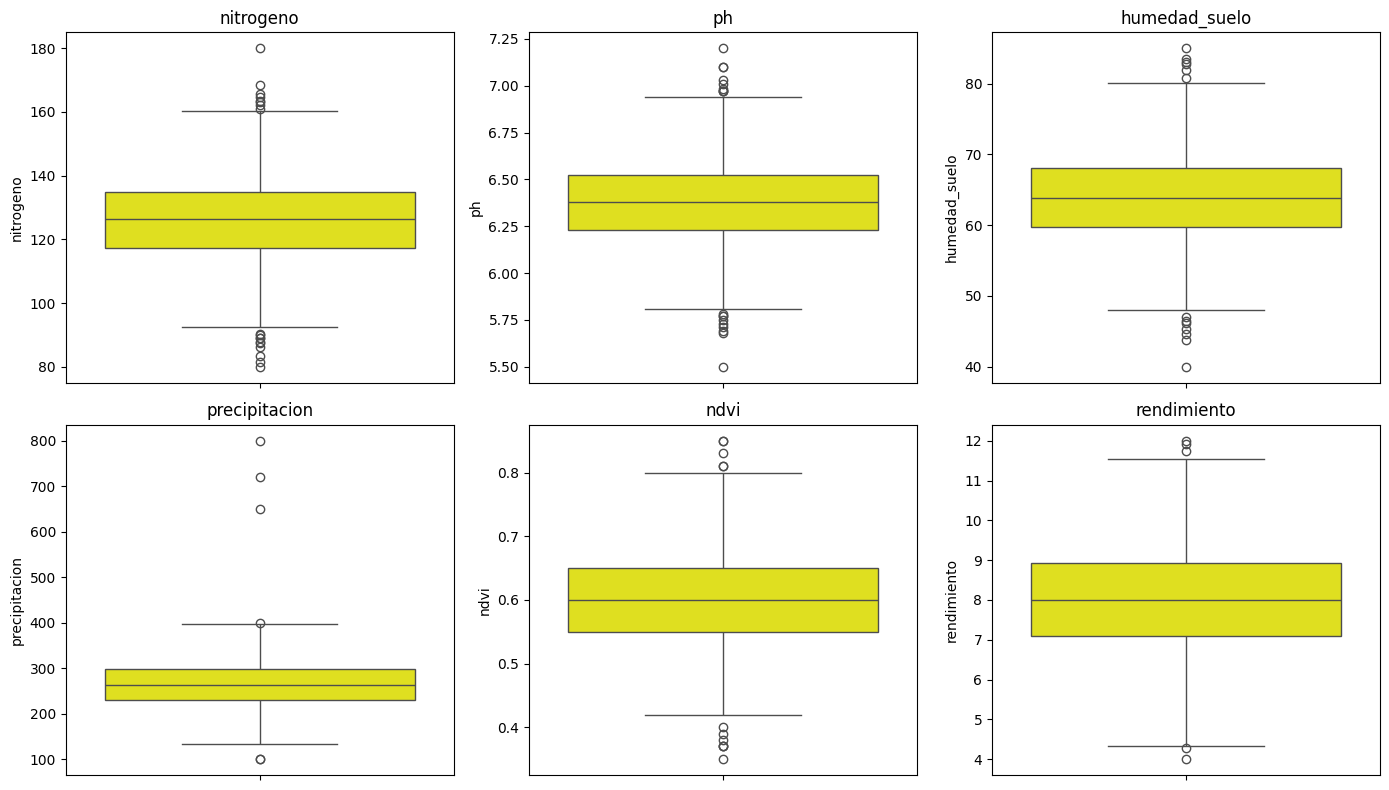

In [89]:
# BOXPLOTS
import matplotlib.pyplot as plt
import seaborn as sns

vars_clave = ['nitrogeno', 'ph', 'humedad_suelo',
              'precipitacion', 'ndvi', 'rendimiento']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(vars_clave):
    sns.boxplot(y=df[col], ax=axes.flatten()[i], color='yellow')
    axes.flatten()[i].set_title(col)
plt.tight_layout()
plt.show()

In [90]:
# Precipitación tiene datos atípicos.****
# pH no presenta anomalías.
# NDVI tiene pocos datos atípicos, pero sí presenta algunos.
# Rendimiento: mediana aproximada de 8 t/ha, con un dato atípico bajo de 4.0 t/ha.

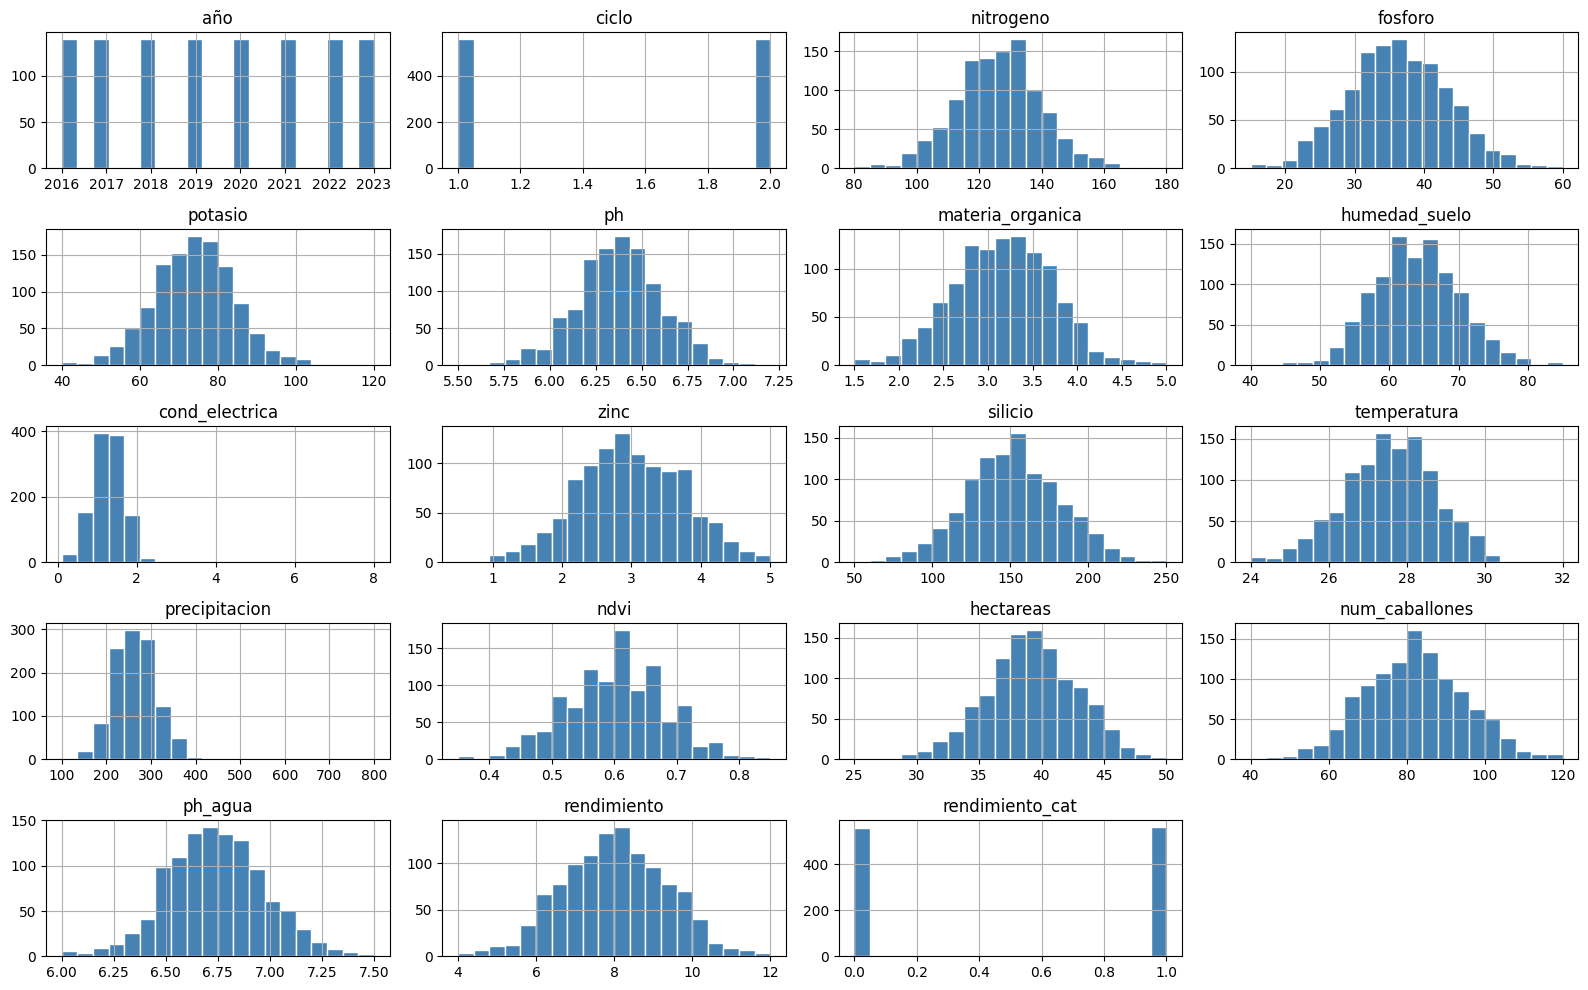

In [91]:
# HISTOGRAMAS
df.hist(figsize=(16, 10), bins=20, color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

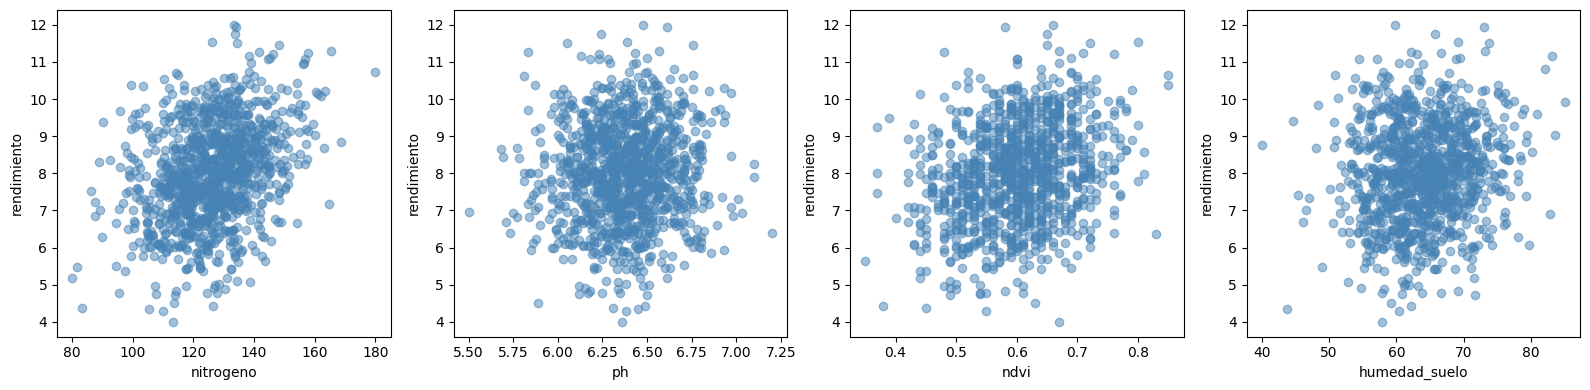

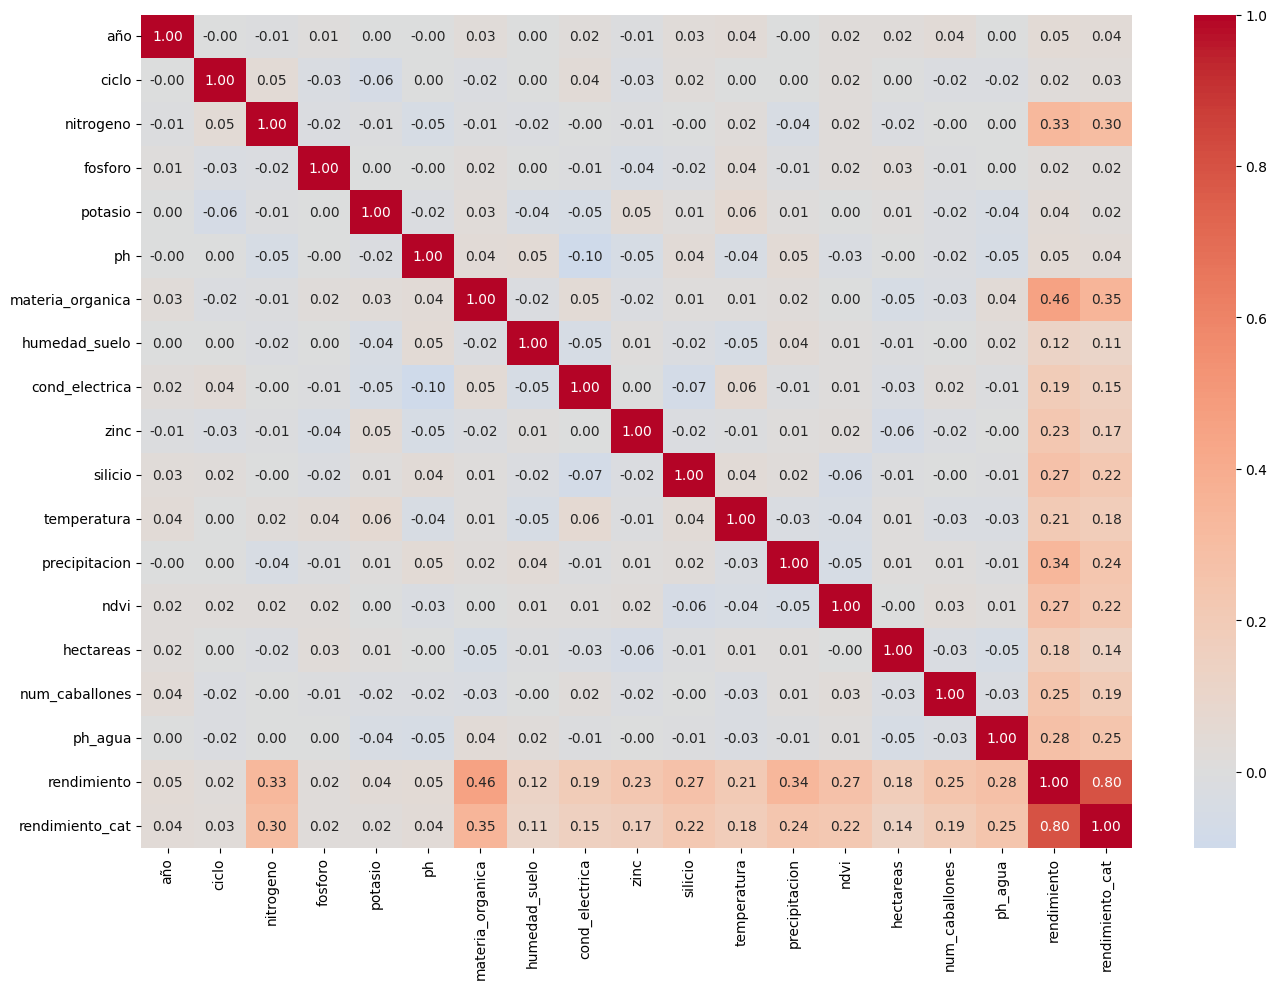

In [92]:
#  DISPERSIÓN Y CORRELACIÓN
vars_disp = ['nitrogeno', 'ph', 'ndvi', 'humedad_suelo']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(vars_disp):
    axes[i].scatter(df[col], df['rendimiento'], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('rendimiento')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include='number').corr().round(2),
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.tight_layout()
plt.show()

In [93]:
#nada se correlaciona con nada de manera uy notoria es rendimiento con rendimiento categorico.si es bueno el redimeinto pues tiene 1.

##Practica Sql

In [94]:
import sqlite3
# CONEXIÓN

conexion = sqlite3.connect('arroz_tolima.db')
#lo guardamos en base datos sql.
df.to_sql('arroz', conexion, if_exists='replace', index=False)
cur = conexion.cursor()
print("Conexión se dio ")

Conexión se dio 


In [95]:
#  RENDIMIENTO PROMEDIO POR LOTE
#from arroz que es la tabla guardada previemnte consulta en ella rendimeinto en promedio
#agrupa todas las filas de un mismo lote para poder promedira.
#finalmente odena en orden de numero prom mayor a menor.
consulta = """
SELECT lote,
       ROUND(AVG(rendimiento), 2) as rendimiento_promedio
FROM arroz
GROUP BY lote
ORDER BY rendimiento_promedio DESC
"""
cur.execute(consulta)
resultado = cur.fetchall()
pd.DataFrame(resultado, columns=['lote', 'rendimiento_promedio'])

,lote,rendimiento_promedio
0,Lote_42,8.77
1,Lote_02,8.68
2,Lote_09,8.64
3,Lote_38,8.61
4,Lote_41,8.59
...,...,...
65,Lote_13,7.49
66,Lote_10,7.41
67,Lote_58,7.36
68,Lote_15,7.16


In [96]:
import sqlite3

conexion = sqlite3.connect('arroz_tolima.db')
cur = conexion.cursor()

# ── MEJORES Y PEORES CICLOS PRODUCTIVOS
consulta_mejor = """
SELECT lote, año, ciclo, ROUND(rendimiento, 2) as rendimiento
FROM arroz
ORDER BY rendimiento DESC
LIMIT 3
"""
consulta_peor = """
SELECT lote, año, ciclo, ROUND(rendimiento, 2) as rendimiento
FROM arroz
ORDER BY rendimiento ASC
LIMIT 3
"""

cur.execute(consulta_mejor)
print("── Top 3 ciclos más productivos ──")
print(pd.DataFrame(cur.fetchall(), columns=['lote', 'año', 'ciclo', 'rendimiento']))

cur.execute(consulta_peor)
print("\n── Top 3 ciclos menos productivos ──")
print(pd.DataFrame(cur.fetchall(), columns=['lote', 'año', 'ciclo', 'rendimiento']))

# ── Promedio por ciclo global
consulta_ciclo = """
SELECT ciclo, ROUND(AVG(rendimiento), 2) as rendimiento_promedio
FROM arroz
GROUP BY ciclo
ORDER BY ciclo
"""
cur.execute(consulta_ciclo)
print("\n── Rendimiento promedio por ciclo (todos los años) ──")
print(pd.DataFrame(cur.fetchall(), columns=['ciclo', 'rendimiento_promedio']))

conexion.close()
print("Conexión se cerró correctamente al finalizar el bloque.")

── Top 3 ciclos más productivos ──
      lote   año  ciclo  rendimiento
0  Lote_42  2017      2        12.00
1  Lote_35  2021      2        11.93
2  Lote_65  2021      2        11.74

── Top 3 ciclos menos productivos ──
      lote   año  ciclo  rendimiento
0  Lote_10  2016      2         4.00
1  Lote_65  2023      2         4.28
2  Lote_15  2023      1         4.33

── Rendimiento promedio por ciclo (todos los años) ──
   ciclo  rendimiento_promedio
0      1                  7.98
1      2                  8.04
Conexión se cerró correctamente al finalizar el bloque.


In [97]:
#cierro conexion
conexion.close()
print(" Conexión se cerro")

 Conexión se cerro


In [98]:
#  DETECCIÓN DE ATÍPICOS CON IQR

cols_revisar = ['precipitacion', 'cond_electrica']

for col in cols_revisar:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    atipicos = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    print(f"{col}: {len(atipicos)} atípicos | límites [{lim_inf:.2f}, {lim_sup:.2f}]")

precipitacion: 6 atípicos | límites [129.41, 398.32]
cond_electrica: 5 atípicos | límites [0.24, 2.29]


In [99]:
# clip reemplaza los valores fuera del rango por el límite más cercano

for col in cols_revisar:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)
    print(f" {col} corregido → min: {df[col].min():.2f} max: {df[col].max():.2f}")

 precipitacion corregido → min: 129.41 max: 398.32
 cond_electrica corregido → min: 0.24 max: 2.29


In [100]:
#imputacion simple
# Ideal para variables de fertilización como nitrógeno y fósforo

from sklearn.impute import SimpleImputer

cols_simple = ['nitrogeno', 'fosforo']

simpleImputer = SimpleImputer(missing_values=np.nan, strategy='mean')
df[cols_simple] = simpleImputer.fit_transform(df[cols_simple])

print(f" SimpleImputer aplicado")
print(f"  Nulos restantes en {cols_simple}: {df[cols_simple].isnull().sum().sum()}")

 SimpleImputer aplicado
  Nulos restantes en ['nitrogeno', 'fosforo']: 0


In [101]:
#su valor no depende de otras colunas la media es suficiente la "mean"

In [102]:
#KNN imputer
# Rellena con el promedio de los k vecinos más similares
# Ideal para humedad y NDVI → dependen de condiciones del lote vecino

from sklearn.impute import KNNImputer

cols_knn = ['humedad_suelo', 'ndvi']

knnImputer = KNNImputer(missing_values=np.nan, n_neighbors=5, weights='uniform')
df[cols_knn] = knnImputer.fit_transform(df[cols_knn])

print(f" KNNImputer aplicado")
print(f"  Nulos restantes en {cols_knn}: {df[cols_knn].isnull().sum().sum()}")

 KNNImputer aplicado
  Nulos restantes en ['humedad_suelo', 'ndvi']: 0


In [103]:
#continua espacialmente dependiente, un lote parecido como mismo suelo y mismo año es mejor referencia que prom global.

In [104]:
#ITERATIVE IMPUTER.
# Usa regresión lineal para predecir el valor faltante
# a partir de las otras columnas → el más preciso de los tres
# Ideal para zinc y silicio → micronutrientes relacionados entre sí

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

cols_iter = ['zinc', 'silicio']

iterativeImputer = IterativeImputer(
    estimator       = LinearRegression(),
    missing_values  = np.nan,
    max_iter        = 10,
    initial_strategy= 'mean',
    random_state    = 42
)
df[cols_iter] = iterativeImputer.fit_transform(df[cols_iter])

print(f" IterativeImputer aplicado")
print(f"  Nulos restantes en {cols_iter}: {df[cols_iter].isnull().sum().sum()}")

# verificación final
print(f"\n  Nulos totales en el dataset: {df.isnull().sum().sum()}")

 IterativeImputer aplicado
  Nulos restantes en ['zinc', 'silicio']: 0

  Nulos totales en el dataset: 0


In [105]:
#continuo y relacionada, entre ellas se relacionan es decir si se el zinc peudo hacer una prediccion de silicio por eso hicimos iterative IMPUTER.

#ROBUST SCALER

In [106]:
#ME BORRA EL EL DATO DE LA MITAD OSEA DE LA MEDIANA Y NO ME SE HACEN COLAS EN LOS ATIPICOS.
#Los atípicos no afectan la mediana ni el IQR — son resistentes a valores extremos.
#xESCALADO = X-MEADIANA/ IQR .

from sklearn.preprocessing import RobustScaler

# Seleccionamos solo las columnas numéricas agronómicas (excluimos año y categorías)
cols_numericas = ['nitrogeno', 'fosforo', 'potasio', 'ph', 'materia_organica',
                  'humedad_suelo', 'cond_electrica', 'zinc', 'silicio',
                  'temperatura', 'precipitacion', 'ndvi', 'hectareas',
                  'num_caballones', 'ph_agua', 'rendimiento']

df_numericas = df[cols_numericas]

# Aplicamos RobustScaler
robust_scaler   = RobustScaler()
robust_scaled   = robust_scaler.fit_transform(df_numericas)

# Lista con: datos sin escalar y datos escalados con RobustScaler
# (misma estructura que el código original de clase)
sin_escalar         = df_numericas.to_numpy()
transformaciones    = [sin_escalar, robust_scaled]

print(" RobustScaler aplicado :) :) :)")
print(f"  Forma del array escalado : {robust_scaled.shape}")
print(f"  Mediana columna nitrogeno (debe ser ≈ 0): {robust_scaled[:, 0].mean():.4f}")

 RobustScaler aplicado :) :) :)
  Forma del array escalado : (1120, 16)
  Mediana columna nitrogeno (debe ser ≈ 0): 0.0000


#PCA

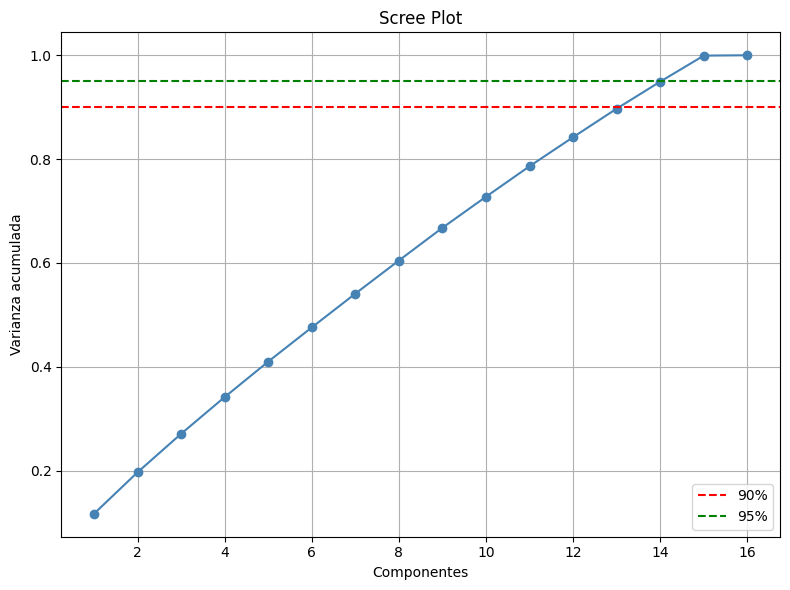

In [107]:
# SCREE PLOT para PCA (principal component analisis)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA()
varianza_acumulada = np.cumsum(pca_full.fit(robust_scaled).explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, marker='o', color='steelblue')
plt.axhline(y=0.90, color='red',   linestyle='--', label='90%')
plt.axhline(y=0.95, color='green', linestyle='--', label='95%')
plt.xlabel("Componentes"); plt.ylabel("Varianza acumulada")
plt.title("Scree Plot"); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

In [108]:
#sigo la linea roja y para que no se me pierda la informacion o más bien conservar el 90 % de la info puedo usar 13 variables.
pca_13 = PCA(n_components=13)
X_pca_13 = pca_13.fit_transform(robust_scaled)

df_pca_13 = pd.DataFrame(
    X_pca_13,
    columns=[f"PC{i}" for i in range(1, 14)], # Changed range to 14 for 13 components
    index=df_numericas.index # Use df_numericas.index as robust_scaled is derived from it
)

print("Varianza explicada acumulada con 13 componentes:",
      pca_13.explained_variance_ratio_.sum())

display(df_pca_13.head())

Varianza explicada acumulada con 13 componentes: 0.897163242021531


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-0.568970,0.598063,-0.527934,1.042706,-0.011422,0.180489,0.458551,0.321726,-0.218643,-0.574298,-0.187697,-0.635677,0.332732
1,0.634031,0.582446,-0.028771,0.285637,0.587291,0.796195,0.148853,-0.850577,-0.168586,-0.900414,1.017317,1.394651,-0.031004
2,1.028278,0.763071,-0.862479,0.546726,-0.972644,0.894682,-0.149136,0.769084,-0.017374,-0.853280,0.909999,0.104080,-1.327459
3,-0.133942,-1.449775,-0.275779,0.190911,1.139595,-0.741792,1.138564,0.031289,-0.058607,1.261075,-0.804037,-1.270228,-0.259182
4,-0.144072,0.873709,-0.466092,0.071866,0.154695,0.155198,0.355256,-1.458010,0.168816,-1.536472,-0.840445,0.338719,0.982565


# Series de tiempo

In [109]:
df['año'].unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [110]:
df['ciclo'].unique()

array([1, 2])

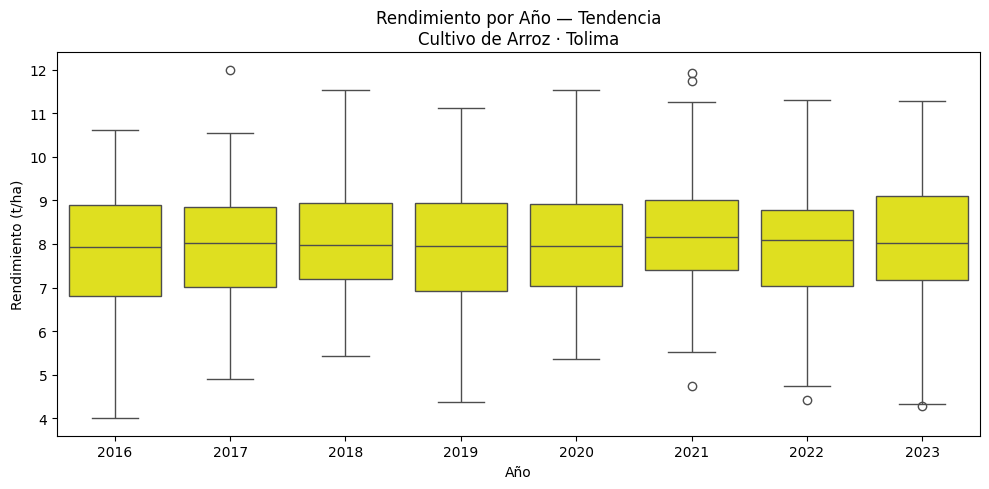

In [111]:

# Visualiza cómo varía el rendimiento año a año en todos los lotes.
# Equivale al "Year-wise Box Plot" del código de clase.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x='año', y='rendimiento', data=df, color='yellow')
plt.title('Rendimiento por Año — Tendencia\nCultivo de Arroz · Tolima')
plt.xlabel('Año'); plt.ylabel('Rendimiento (t/ha)')
plt.tight_layout(); plt.show()

2019 tuvo menos diferencias entre yields de lotes.  
2017 un desastre de diferencias.  
2023 caja más desplazada hacia arriba y línea más alta. Le siguen 2020 / 2023.  
2018 menor producción.

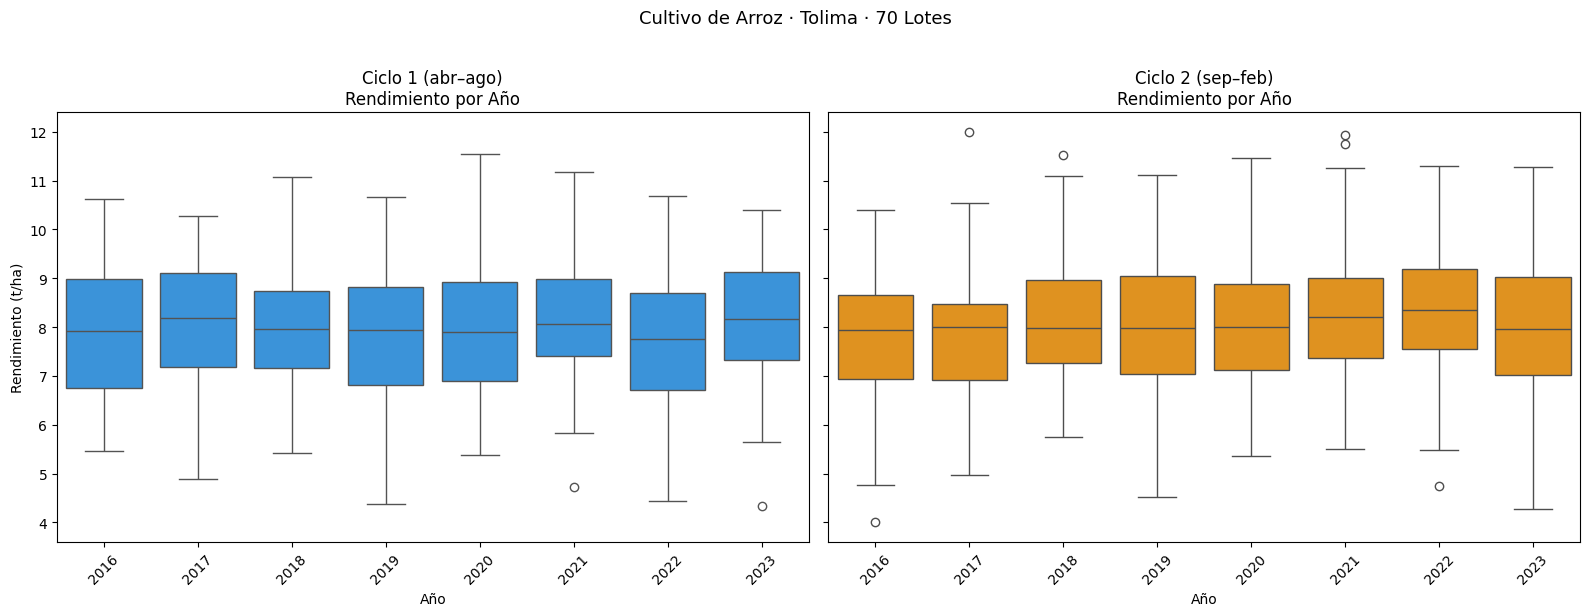


Ciclo 1 — promedio por año:
año
2016    7.92
2017    8.09
2018    8.01
2019    7.84
2020    7.94
2021    8.15
2022    7.70
2023    8.20
Name: rendimiento, dtype: float64

Ciclo 2 — promedio por año:
año
2016    7.79
2017    7.81
2018    8.07
2019    8.04
2020    8.05
2021    8.34
2022    8.24
2023    7.98
Name: rendimiento, dtype: float64


In [112]:
# RENDIMIENTO POR AÑO CICLO 1 Y CICLO 2 SEPARADOS

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ── Ciclo 1
sns.boxplot(
    data    = df[df['ciclo'] == 1],
    x       = 'año',
    y       = 'rendimiento',
    color   = '#2196F3',
    ax      = axes[0]
)
axes[0].set_title('Ciclo 1 (abr–ago)\nRendimiento por Año', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Rendimiento (t/ha)')
axes[0].tick_params(axis='x', rotation=45)

# ── Ciclo 2
sns.boxplot(
    data    = df[df['ciclo'] == 2],
    x       = 'año',
    y       = 'rendimiento',
    color   = '#FF9800',
    ax      = axes[1]
)
axes[1].set_title('Ciclo 2 (sep–feb)\nRendimiento por Año', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Cultivo de Arroz · Tolima · 70 Lotes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nCiclo 1 — promedio por año:")
print(df[df['ciclo']==1].groupby('año')['rendimiento'].mean().round(2))
print("\nCiclo 2 — promedio por año:")
print(df[df['ciclo']==2].groupby('año')['rendimiento'].mean().round(2))

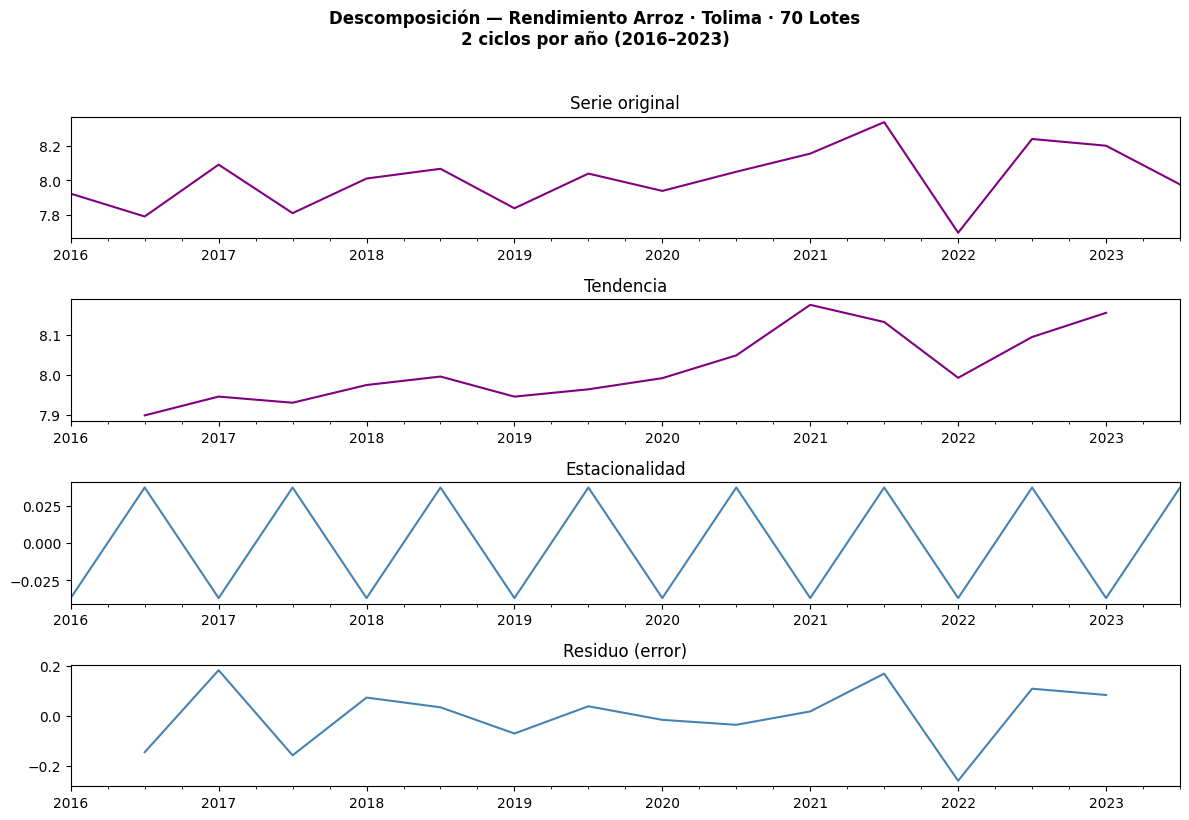

In [113]:

# Separamos el rendimiento promedio en sus 3 componentes:
# Tendencia + Estacionalidad + Residuo (error)
# Agrupamos por año Y ciclo para capturar los 2 ciclos productivos del arroz

from statsmodels.tsa.seasonal import seasonal_decompose

# Serie: promedio de los 70 lotes por año y ciclo
rendimiento_serie = (
    df.groupby(['año', 'ciclo'])['rendimiento']
    .mean()
    .reset_index()
    .sort_values(['año', 'ciclo'])
)

# Convertimos a serie temporal con frecuencia semestral (2 ciclos por año)
rendimiento_anual = pd.Series(
    rendimiento_serie['rendimiento'].values,
    index = pd.date_range(start='2016-01', periods=16, freq='6ME')
)

# Descomposición — period=2 porque hay 2 ciclos por año
descomposicion = seasonal_decompose(rendimiento_anual, model='additive', period=2)

fig, axes = plt.subplots(4, 1, figsize=(12, 8))
descomposicion.observed.plot(ax=axes[0], title='Serie original',      color='purple')
descomposicion.trend.plot(   ax=axes[1], title='Tendencia',           color='purple')
descomposicion.seasonal.plot(ax=axes[2], title='Estacionalidad',      color='steelblue')
descomposicion.resid.plot(   ax=axes[3], title='Residuo (error)',      color='steelblue')

plt.suptitle('Descomposición — Rendimiento Arroz · Tolima · 70 Lotes\n2 ciclos por año (2016–2023)',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()



Residuo Error = Serie original − Tendencia −Estacionalidad.  
esto no se puede explicar con la estacionalidad.

In [114]:
# p-value < 0.05 → estacionaria | p-value > 0.05 → no estacionaria
# Usamos rendimiento_serie que ya tiene los 2 ciclos por año (16 puntos)

from statsmodels.tsa.stattools import adfuller

result = adfuller(rendimiento_anual.values, autolag='AIC')
print(f'p-value    : {result[1]:.4f}')


p-value    : 1.0000



1.00 es mayor que 0.05, entonces NO ESTACIONARIA.   
no se va a volver estacionaria segun el codigo visto en clase por que no se quieren sacrificar datos. ademas el dicker fulleu funciona mehor con 20- 30 datos aca solo tebemos 8 . se trabaja con la serie original, aceptando que presenta una
tendencia leve propia del comportamiento del cultivo.



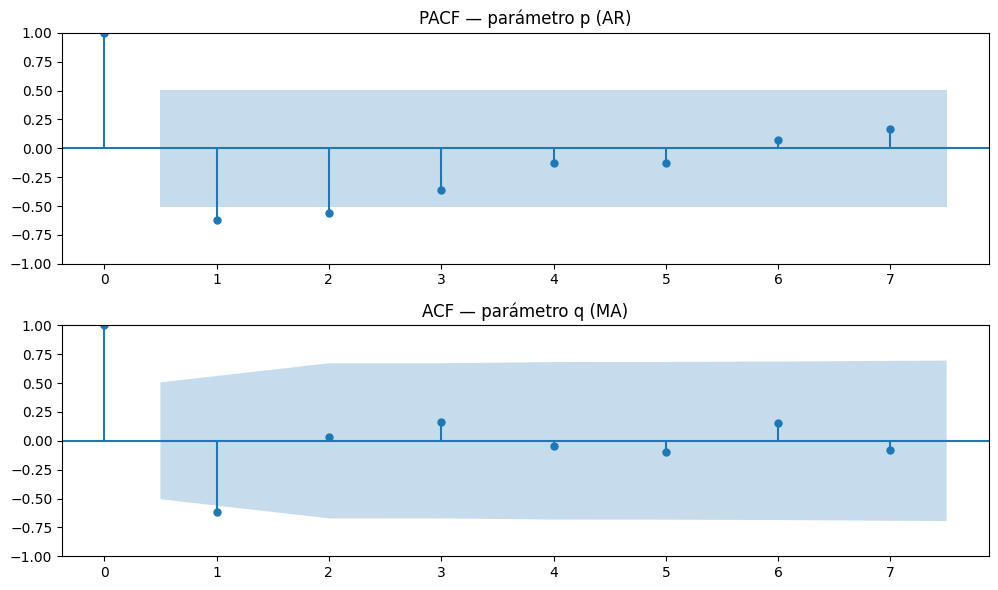

In [115]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Serie: promedio de 70 lotes por año y ciclo → 16 puntos
subset = (
    df.groupby(['año', 'ciclo'])['rendimiento']
    .mean()
    .reset_index(drop=True)
)
subset.index = pd.date_range(start='2016-01', periods=16, freq='6ME')

# Diferenciar para hacerla estacionaria
ts_diff = subset.diff().dropna()

# ACF y PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_pacf(ts_diff, ax=ax1, lags=7)
ax1.set_title('PACF — parámetro p (AR)')
plot_acf(ts_diff, ax=ax2, lags=7)
ax2.set_title('ACF — parámetro q (MA)')
plt.tight_layout()
plt.show()

In [116]:
#parametro p es lag 2 Q lag 1.

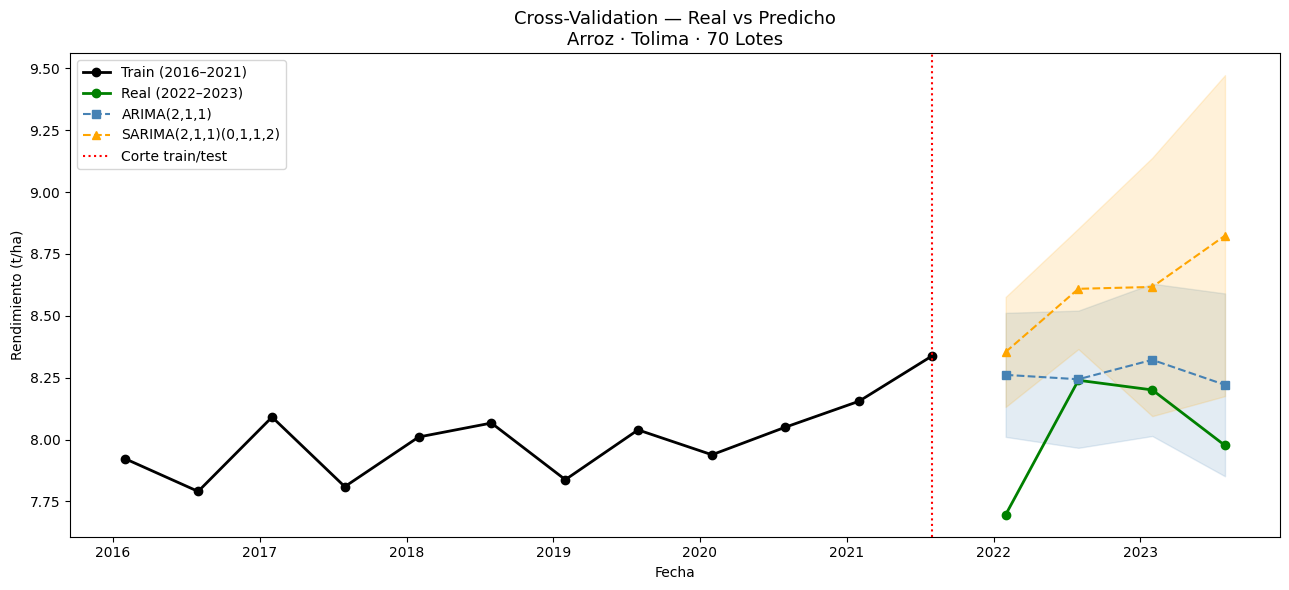


Real vs Predicho:
       fecha  real  ARIMA  SARIMA
0 2022-01-31  7.70   8.26    8.35
1 2022-07-31  8.24   8.24    8.61
2 2023-01-31  8.20   8.32    8.62
3 2023-07-31  7.98   8.22    8.82

ARIMA  — MAE: 0.234 t/ha
SARIMA — MAE: 0.573 t/ha

→ Gana: ARIMA


In [117]:
# ─── CROSS-VALIDATION — ENTRENA HASTA 2021, PREDICE 2022-2023 ────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ── Separar train y test
# subset tiene 16 puntos (2016-2023, 2 ciclos/año)
# train: primeros 12 puntos (2016–2021)
# test:  últimos  4 puntos  (2022–2023)
train = subset.iloc[:12]
test  = subset.iloc[12:]

# ── ARIMA(2,1,1)
arima  = ARIMA(train, order=(2,1,1)).fit()
pred_arima  = arima.get_forecast(steps=4)
ci_arima    = pred_arima.conf_int()

# ── SARIMA(2,1,1)(0,1,1,2)
sarima = SARIMAX(train, order=(2,1,1), seasonal_order=(0,1,1,2)).fit(disp=False, max_iter=1000)
pred_sarima = sarima.get_forecast(steps=4)
ci_sarima   = pred_sarima.conf_int()

# ── Gráfica
plt.figure(figsize=(13, 6))

# Histórico train
plt.plot(train.index, train.values, 'o-', color='black', label='Train (2016–2021)', linewidth=2)

# Real test
plt.plot(test.index, test.values, 'o-', color='green', label='Real (2022–2023)', linewidth=2)

# ARIMA predicho
plt.plot(test.index, pred_arima.predicted_mean, 's--', color='steelblue', label='ARIMA(2,1,1)')
plt.fill_between(test.index, ci_arima.iloc[:,0], ci_arima.iloc[:,1], alpha=0.15, color='steelblue')

# SARIMA predicho
plt.plot(test.index, pred_sarima.predicted_mean, '^--', color='orange', label='SARIMA(2,1,1)(0,1,1,2)')
plt.fill_between(test.index, ci_sarima.iloc[:,0], ci_sarima.iloc[:,1], alpha=0.15, color='orange')

plt.axvline(x=train.index[-1], color='red', linestyle=':', linewidth=1.5, label='Corte train/test')
plt.title('Cross-Validation — Real vs Predicho\nArroz · Tolima · 70 Lotes', fontsize=13)
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (t/ha)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Tabla comparativa real vs predicho
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("\nReal vs Predicho:")
print(pd.DataFrame({
    'fecha'         : test.index,
    'real'          : test.values.round(2),
    'ARIMA'         : pred_arima.predicted_mean.round(2).values,
    'SARIMA'        : pred_sarima.predicted_mean.round(2).values,
}))

print(f"\nARIMA  — MAE: {mean_absolute_error(test, pred_arima.predicted_mean):.3f} t/ha")
print(f"SARIMA — MAE: {mean_absolute_error(test, pred_sarima.predicted_mean):.3f} t/ha")
print(f"\n→ Gana: {'ARIMA' if mean_absolute_error(test, pred_arima.predicted_mean) < mean_absolute_error(test, pred_sarima.predicted_mean) else 'SARIMA'}")

In [118]:
#no funciono ninguno de los dos, pero el mas real es Arima. Mae menor osea equivoco menos.Si tuvieramos mas puntos la predicción seria mejor

##Division datos en entrenamiento y prueba

In [119]:

# 80% entrenamiento, 20% prueba.
# X: variables agronómicas escaladas | y: rendimiento_cat (0=bajo, 1=alto)

from sklearn.model_selection import train_test_split

X = robust_scaled[:, :-1]
y = df['rendimiento_cat'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (896, 15) | X_test: (224, 15)
y_train: (896,) | y_test: (224,)


## Modelos

Lasso

In [120]:
#LASSO . Tiene 12 iteraciones de cual es que que da menos error elige ese.
# el pasa por todos y esgoce las variebles mas importantes y las que no
from sklearn import linear_model

#Instanciar el modelo de Regresión Lineal Lasso
lasso = linear_model.LassoCV(cv=5, max_iter=5000, alphas=[0.0001, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0])

#Ajustar el modelo a los datos de entrenamiento
lasso.fit(X_train, y_train)

LassoCV(alphas=[0.0001, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.3, 0.5,
                0.8, 1.0],
        cv=5, max_iter=5000)

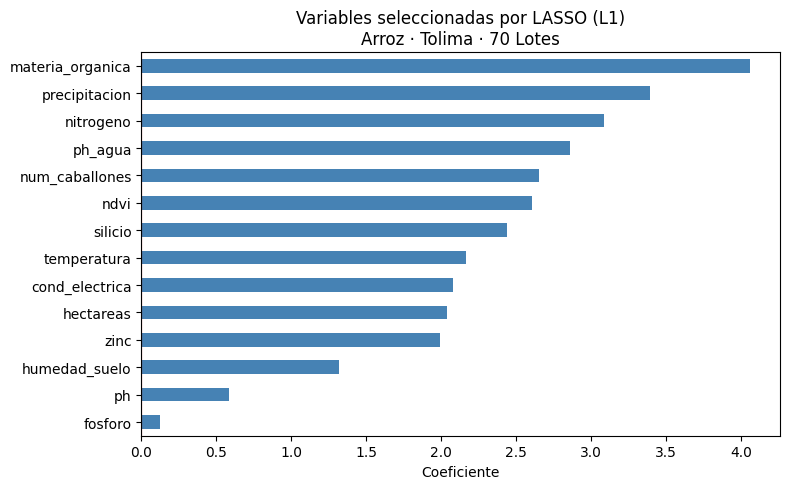

In [121]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# ── Instanciar y entrenar
lasso_clf = LogisticRegressionCV(
    cv       = 5,
    penalty  = 'l1',
    solver   = 'liblinear',   # único solver compatible con L1
    Cs       = [100, 10, 1, 0.5, 0.1, 0.01, 0.001],
    random_state = 42
)
lasso_clf.fit(X_train, y_train)

# ── Gráfica de coeficientes
# Definir 'coefs' a partir de los coeficientes del modelo
coefs = pd.Series(lasso_clf.coef_[0], index=cols_numericas[:-1])
coefs_importantes = coefs[coefs != 0].sort_values()
plt.figure(figsize=(8, 5))
coefs_importantes.plot(kind='barh', color='steelblue')
plt.axvline(x=0, color='red', linewidth=0.8)
plt.title('Variables seleccionadas por LASSO (L1)\nArroz · Tolima · 70 Lotes')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

Mejor alpha: 0.00010
RMSE LASSO : 0.3034 t/ha
R²   LASSO : 0.9496
MAE  LASSO : 0.1630 t/ha

Variables seleccionadas : 15
Variables eliminadas    : 0


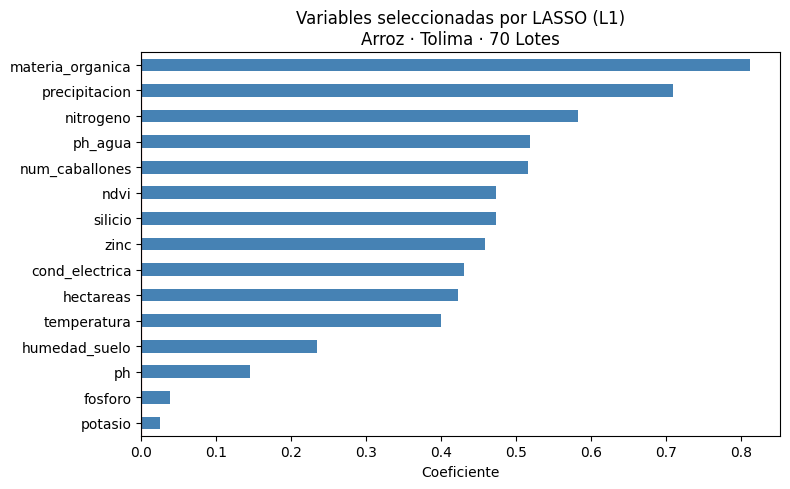

In [122]:
# ─── LASSO — REGRESIÓN CON PENALIZACIÓN L1 ───────────────────────────────────
# LassoCV ajusta el mejor alpha con validación cruzada.
# Lleva coeficientes a cero → selección automática de variables.
# Métricas de regresión: RMSE, R² y MAE.

from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Variable objetivo continua (rendimiento en t/ha)
X_reg = robust_scaled[:, :-1]
y_reg = df['rendimiento'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# ── Instanciar y entrenar
lasso_reg = LassoCV(
    cv       = 5,
    alphas   = [0.0001, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0],
    max_iter = 5000,
    random_state = 42
)
lasso_reg.fit(X_train_r, y_train_r)

# ── Predicciones
y_pred_lasso = lasso_reg.predict(X_test_r)

# ── Métricas de regresión
rmse_lasso = np.sqrt(mean_squared_error(y_test_r, y_pred_lasso))
r2_lasso   = r2_score(y_test_r, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test_r, y_pred_lasso)

print(f"Mejor alpha: {lasso_reg.alpha_:.5f}")
print(f"RMSE LASSO : {rmse_lasso:.4f} t/ha")
print(f"R²   LASSO : {r2_lasso:.4f}")
print(f"MAE  LASSO : {mae_lasso:.4f} t/ha")

# ── Variables seleccionadas vs eliminadas
coefs_lasso = pd.Series(lasso_reg.coef_, index=cols_numericas[:-1])
print(f"\nVariables seleccionadas : {(coefs_lasso != 0).sum()}")
print(f"Variables eliminadas    : {(coefs_lasso == 0).sum()}")

# ── Gráfica de coeficientes
coefs_importantes_lasso = coefs_lasso[coefs_lasso != 0].sort_values()
plt.figure(figsize=(8, 5))
coefs_importantes_lasso.plot(kind='barh', color='steelblue')
plt.axvline(x=0, color='red', linewidth=0.8)
plt.title('Variables seleccionadas por LASSO (L1)\nArroz · Tolima · 70 Lotes')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

Ridge

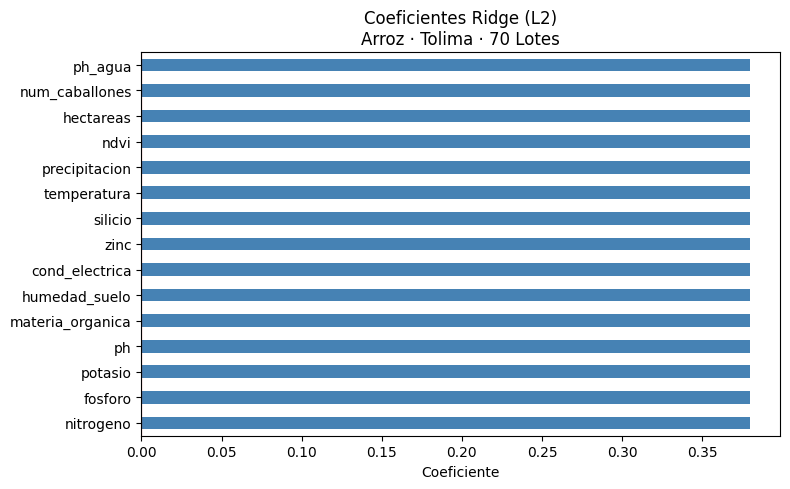

In [123]:
# RidgeClassifier l al cuadrado antes de sumar. usa todas las variables no elimina
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# ── Instanciar y entrenar
ridge = RidgeClassifier()
ridge.fit(X_train, y_train)


# ── Gráfica de coeficientes
coefs_ridge = pd.Series(ridge.coef_[0], index=cols_numericas[:-1]).sort_values()

plt.figure(figsize=(8, 5))
coefs_ridge.plot(kind='barh', color='steelblue')
plt.axvline(x=0, color='red', linewidth=0.8)
plt.title('Coeficientes Ridge (L2)\nArroz · Tolima · 70 Lotes')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

Mejor alpha: 0.10000
RMSE Ridge : 0.3034 t/ha
R²   Ridge : 0.9496
MAE  Ridge : 0.1629 t/ha


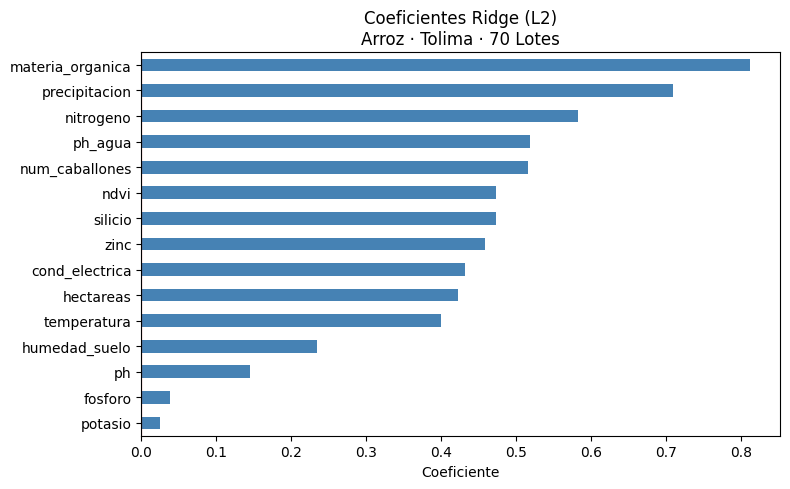


── Comparativa LASSO vs Ridge ──
Modelo         RMSE       R²      MAE
LASSO        0.3034   0.9496   0.1630
Ridge        0.3034   0.9496   0.1629


In [124]:
# ─── RIDGE — REGRESIÓN CON PENALIZACIÓN L2 ───────────────────────────────────
# RidgeCV ajusta el mejor alpha con validación cruzada.
# No elimina variables, penaliza (achica) los coeficientes grandes.
# Métricas de regresión: RMSE, R² y MAE.

from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Instanciar y entrenar (usa los mismos X_train_r / X_test_r del bloque anterior)
ridge_reg = RidgeCV(
    alphas = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    cv     = 5
)
ridge_reg.fit(X_train_r, y_train_r)

# ── Predicciones
y_pred_ridge = ridge_reg.predict(X_test_r)

# ── Métricas de regresión
rmse_ridge = np.sqrt(mean_squared_error(y_test_r, y_pred_ridge))
r2_ridge   = r2_score(y_test_r, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test_r, y_pred_ridge)

print(f"Mejor alpha: {ridge_reg.alpha_:.5f}")
print(f"RMSE Ridge : {rmse_ridge:.4f} t/ha")
print(f"R²   Ridge : {r2_ridge:.4f}")
print(f"MAE  Ridge : {mae_ridge:.4f} t/ha")

# ── Gráfica de coeficientes
coefs_ridge = pd.Series(ridge_reg.coef_, index=cols_numericas[:-1]).sort_values()

plt.figure(figsize=(8, 5))
coefs_ridge.plot(kind='barh', color='steelblue')
plt.axvline(x=0, color='red', linewidth=0.8)
plt.title('Coeficientes Ridge (L2)\nArroz · Tolima · 70 Lotes')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

# ── Comparativa final de los dos modelos
print("\n── Comparativa LASSO vs Ridge ──")
print(f"{'Modelo':<10} {'RMSE':>8} {'R²':>8} {'MAE':>8}")
print(f"{'LASSO':<10} {rmse_lasso:>8.4f} {r2_lasso:>8.4f} {mae_lasso:>8.4f}")
print(f"{'Ridge':<10} {rmse_ridge:>8.4f} {r2_ridge:>8.4f} {mae_ridge:>8.4f}")

Árbol

In [125]:
from sklearn.tree import DecisionTreeClassifier, plot_tree # Added this import
from sklearn.metrics import accuracy_score, classification_report # Added this import

# ── Árbol con más profundidad
dtc = DecisionTreeClassifier(
    max_depth        = 6,   # más preguntas → mejor clasificación
    min_samples_leaf = 10,  # minimamente me lo va a dividir 10 veces para que el se entrene.
    random_state     = 42
)
dtc.fit(X_train, y_train)
dtc_predictions = dtc.predict(X_test)

print(f"Accuracy Árbol: {accuracy_score(y_test, dtc_predictions):.4f}")
print(classification_report(y_test, dtc_predictions))

Accuracy Árbol: 0.6830
              precision    recall  f1-score   support

           0       0.69      0.64      0.66       110
           1       0.67      0.73      0.70       114

    accuracy                           0.68       224
   macro avg       0.68      0.68      0.68       224
weighted avg       0.68      0.68      0.68       224



In [126]:
#se equivoca 1 de cada 3 veces. MEDIOCRE
# el randoom state es 42 para todos.
#max_depth = 3  →  bueno para VISUALIZAR el árbol
#max_depth = 6  →  balance entre complejidad y rendimiento
#max_depth = None → árbol crece libre → overfitting

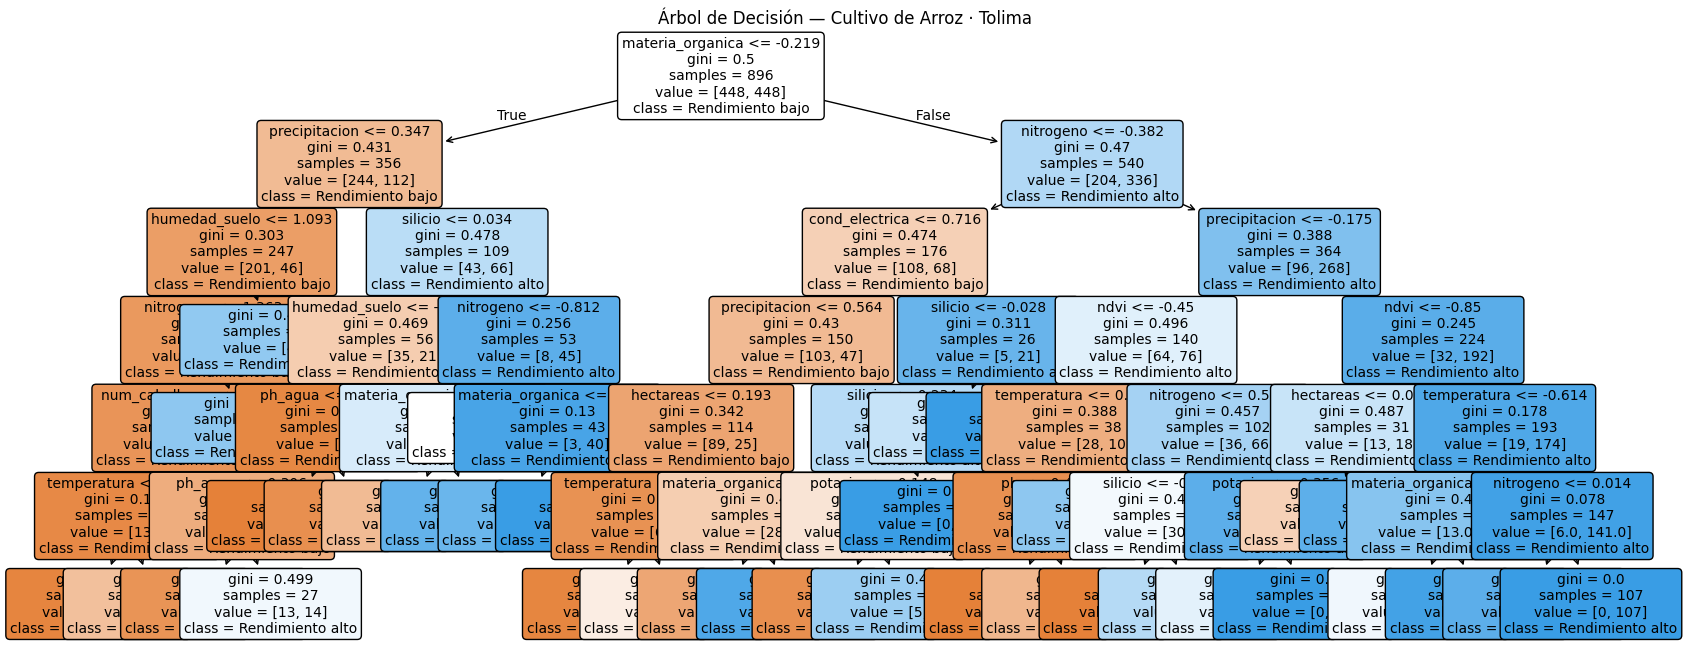

In [127]:
#  VISUALIZACIÓN DEL ÁRBOL
# Graficamos el árbol para ver qué preguntas hace sobre las variables.

plt.figure(figsize=(20, 8))
plot_tree(dtc,
          feature_names=cols_numericas[:-1],
          class_names=['Rendimiento bajo', 'Rendimiento alto'],
          filled=True, rounded=True, fontsize=10)
plt.title('Árbol de Decisión — Cultivo de Arroz · Tolima')
plt.show()

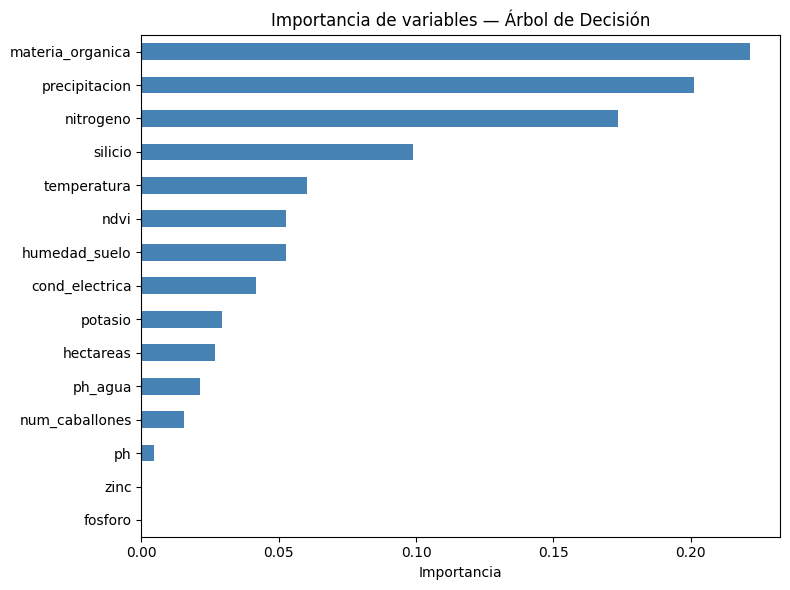

In [128]:
# ─── BLOQUE 12C: IMPORTANCIA DE VARIABLES ────────────────────────────────────
# El árbol le asigna un peso a cada variable según cuánto aportó
# a las decisiones. Variables con importancia 0 fueron ignoradas.

importancias = pd.Series(dtc.feature_importances_, index=cols_numericas[:-1])
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importancia de variables — Árbol de Decisión')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

Bosque

In [129]:
#bolsa vista en clase
# El bosque entrena muchos árboles sobre subconjuntos aleatorios del dataset
# y combina sus votos. Generalmente supera al árbol individual.
# n_estimators = número de árboles en el bosque.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rfc = RandomForestClassifier(
    n_estimators      = 200,   # número de árboles
    max_depth         = 8,     # profundidad de cada árbol individual
    min_samples_leaf  = 5,     # mínimo registros en hoja de cada árbol
    min_samples_split = 10,    # mínimo para dividir un nodo
    max_features      = 'sqrt',# variables a considerar en cada split → √14 ≈ 4
    bootstrap         = True,  # cada árbol entrena con muestra aleatoria del dataset
    random_state      = 42
)

rfc.fit(X_train, y_train)
rfc_predictions = rfc.predict(X_test)

print(f"Accuracy Bosque: {accuracy_score(y_test, rfc_predictions):.4f}")
print(classification_report(y_test, rfc_predictions))

Accuracy Bosque: 0.7946
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       110
           1       0.79      0.82      0.80       114

    accuracy                           0.79       224
   macro avg       0.80      0.79      0.79       224
weighted avg       0.79      0.79      0.79       224



svm

In [130]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Instanciar y entrenar
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)

# Predicciones
svm_predictions = svm.predict(X_test)

# Métricas
print(f"Accuracy SVM: {accuracy_score(y_test, svm_predictions):.4f}")
print(classification_report(y_test, svm_predictions))

Accuracy SVM: 0.9107
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       110
           1       0.91      0.92      0.91       114

    accuracy                           0.91       224
   macro avg       0.91      0.91      0.91       224
weighted avg       0.91      0.91      0.91       224



ANN

In [131]:


from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instanciar y entrenar
ann = MLPClassifier(hidden_layer_sizes=(10, 10, 10),
                    activation='relu',#facil para pocas capas
                    solver='adam',# beno para datasets medianos
                    max_iter=500,
                    random_state=42)
ann.fit(X_train, y_train)

# Predicciones
ann_predictions = ann.predict(X_test)

# Métricas
print(f"Accuracy ANN: {accuracy_score(y_test, ann_predictions):.4f}")
print(classification_report(y_test, ann_predictions))

Accuracy ANN: 0.9241
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       110
           1       0.89      0.96      0.93       114

    accuracy                           0.92       224
   macro avg       0.93      0.92      0.92       224
weighted avg       0.93      0.92      0.92       224



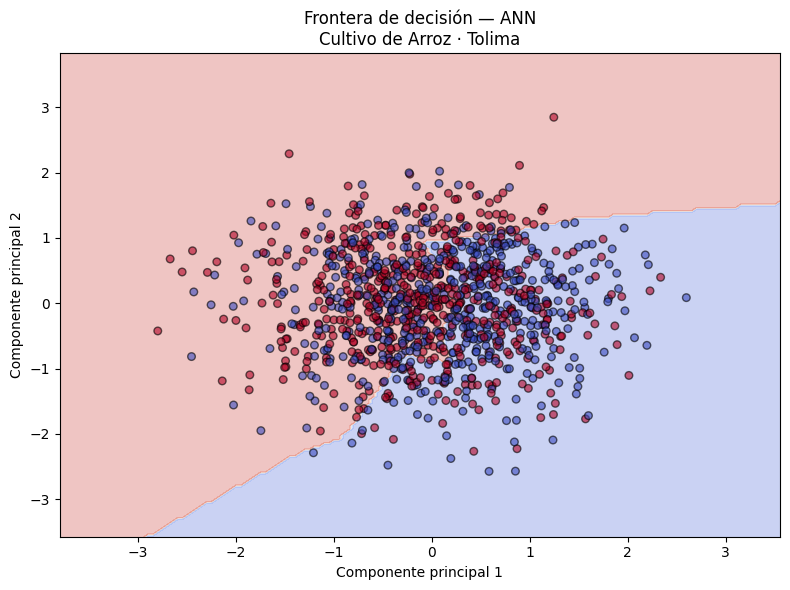

In [132]:
# Perfecto, pero como ya vimos el problema — tienes 15 variables y la frontera necesita 2D. La solución es usar las **2 primeras componentes del PCA** que ya tienes calculado, así podemos graficar en 2D y la frontera tiene sentido.

# Quedaría así:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reducir a 2 componentes solo para visualización
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(robust_scaled[:, :-1])

# Entrenar ANN sobre las 2 componentes
ann_2d = MLPClassifier(hidden_layer_sizes=(10, 10, 10),
                       activation='relu', solver='adam',
                       max_iter=500, random_state=42)
ann_2d.fit(X_2d, y)

# Crear la malla de puntos para graficar la frontera
paso = 0.05
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, paso),
                     np.arange(y_min, y_max, paso))

# Predicción sobre cada punto de la malla
Z = ann_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Puntos reales encima
colores = ['red' if c == 0 else 'blue' for c in y]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm',
            edgecolors='k', alpha=0.6, s=30)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Frontera de decisión — ANN\nCultivo de Arroz · Tolima')
plt.tight_layout()
plt.show()
# ```

# Pégalo y vemos cómo separa la red las dos clases de rendimiento.